# Pandas — Exploração dos dados

In [125]:
import pandas as pd
# Importa a biblioteca pandas e apelida como 'pd' para ficar mais fácil

In [126]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")
# Carrega os dados do arquivo CSV diretamente de uma URL para um DataFrame com o nome 'df'.

In [127]:
df.head(10)
# Exibe as 10 primeiras linhas do df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [128]:
df.info()
# Exibe resumo do df, inclui: tipo de dados, contagem de não-nulos e uso de memória

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [129]:
df.describe()
# Exibe estatísticas descritivas das colunas numéricas do DataFrame, como média, desvio padrão, mínimo, máximo e quartis.

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [130]:
df.shape
# Exibe as dimensões do df (numero de linhas e colunas)

(133349, 11)

In [131]:
linhas, colunas = df.shape[0], df.shape[1]
print ("Nº Linhas:", linhas)
print ("Nº Colunas:", colunas)

# Extrai o numero de linhas e colunas do df.

Nº Linhas: 133349
Nº Colunas: 11


In [132]:
df.columns
# Exibe os nomes das colunas do df

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [133]:
#Dicionário de mapeamento das colunas de inglês para português
colunas_pt = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'tipoEmprego',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'salario_usd',
    'employee_residence': 'paisFunc',
    'remote_ratio': 'txRemoto',
    'company_location': 'paisEmpresa',
    'company_size': 'porte'
}

# Renomeia as colunas do df
df.rename(columns=colunas_pt, inplace=True)

# Exibe as novas colunas
df.columns

Index(['ano', 'senioridade', 'tipoEmprego', 'cargo', 'salario', 'moeda',
       'salario_usd', 'paisFunc', 'txRemoto', 'paisEmpresa', 'porte'],
      dtype='object')

In [134]:
df['senioridade'].value_counts()
# Conta a frequência de cada valor único na coluna 'senioridade'

,count
senioridade,
SE,77241
MI,40465
EN,12443
EX,3200


In [135]:
# Substitui os valores na coluna 'senioridade'
df['senioridade'] = df['senioridade'].replace({
    'MI': 'Pleno',
    'SE': 'Sênior',
    'EN': 'Júnior',
    'EX': 'Executivo'
})

df['senioridade'].value_counts()

,count
senioridade,
Sênior,77241
Pleno,40465
Júnior,12443
Executivo,3200


In [136]:
df['tipoEmprego'] = df['tipoEmprego'].replace({
    'FT': 'Tempo Integral',
    'CT': 'Contrato',
    'PT': 'Tempo Parcial',
    'FL': 'Freelance'
})

df['tipoEmprego'].value_counts()

,count
tipoEmprego,
Tempo Integral,132563
Contrato,394
Tempo Parcial,376
Freelance,16


In [137]:
df['porte'] = df['porte'].replace({
    'M': 'Médio',
    'L': 'Grande',
    'S': 'Pequeno'
})

df['porte'].value_counts()

,count
porte,
Médio,129561
Grande,3574
Pequeno,214


In [138]:
df['txRemoto'] = df['txRemoto'].replace({
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
})

df['txRemoto'].value_counts()

,count
txRemoto,
Presencial,105312
Remoto,27718
Híbrido,319


In [139]:
df.head()

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Médio
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Médio
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Médio
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Médio
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Médio


In [140]:
df.describe(include="object")
# Exibe as estatísticas descritivas das colunas não numéricas, como contagem, valores únicos, valor mais frequente e sua frequência.

,senioridade,tipoEmprego,cargo,moeda,paisFunc,txRemoto,paisEmpresa,porte
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Sênior,Tempo Integral,Data Scientist,USD,US,Presencial,US,Médio
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [141]:
df.isnull()
# Verifica se há valores nulos em cada célula do df

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [142]:
df.isnull().sum()
# Calcula a soma dos valores nulos em cada coluna do df

,0
ano,10
senioridade,0
tipoEmprego,0
cargo,0
salario,0
moeda,0
salario_usd,0
paisFunc,0
txRemoto,0
paisEmpresa,0


In [143]:
df['ano'].unique()
# exibe os valores únicos presentes na coluna 'ano' do df

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [144]:
df[df.isnull().any(axis=1)]
# Filtre o df e exibe apenas linhas com pelo menos um valor nulo

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte
5588,NaN,Sênior,Tempo Integral,Product Manager,184500,USD,184500,US,Presencial,US,Médio
59692,NaN,Pleno,Tempo Integral,Engineer,110000,USD,110000,DE,Presencial,DE,Médio
59710,NaN,Júnior,Tempo Integral,Data Scientist,208800,USD,208800,US,Presencial,US,Médio
59759,NaN,Sênior,Tempo Integral,Software Engineer,135000,USD,135000,US,Presencial,US,Médio
59789,NaN,Sênior,Tempo Integral,Engineer,112000,USD,112000,US,Presencial,US,Médio
131000,NaN,Sênior,Tempo Integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,Médio
131006,NaN,Sênior,Tempo Integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,Médio
133054,NaN,Júnior,Tempo Integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,Grande
133281,NaN,Pleno,Tempo Integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,Grande
133317,NaN,Pleno,Tempo Integral,Data Scientist,130000,USD,130000,US,Híbrido,US,Grande


# Pandas — Preparação e limpeza dos dados

In [145]:
import numpy as np

In [146]:
df_salarios = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Daniele'],
    'salario': [4000, np.nan, 5000, np.nan]
})
# Cria um df do pandas chamado 'df_salarios'

In [147]:
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))
# Preenche os valores nulos da coluna 'salario' usando a média dos salários existentes

In [148]:
df_salarios['salario_mediana'] =df_salarios['salario'].fillna(df_salarios['salario'].median())

In [149]:
df_salarios

,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.0,4000.0
1,Bruno,NaN,4500.0,4500.0
2,Carlos,5000.0,5000.0,5000.0
3,Daniele,NaN,4500.0,4500.0


In [150]:
df_temperaturas = pd.DataFrame({
    'Dia': ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    'Temperatura':[30, np.nan, np.nan, 28, 27]
})

In [151]:
df_temperaturas['Preenchido_ffill'] = df_temperaturas['Temperatura'].ffill()
# Preenche os dados nulos da coluna temperatura com o último valor lido

In [152]:
df_temperaturas

,Dia,Temperatura,Preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [153]:
df_temperaturas['Preenchido_bfill'] = df_temperaturas['Temperatura'].bfill()
# preenche os valores nulos com o próximo valor válido lido

df_temperaturas

,Dia,Temperatura,Preenchido_ffill,Preenchido_bfill
0,Segunda,30.0,30.0,30.0
1,Terça,NaN,30.0,28.0
2,Quarta,NaN,30.0,28.0
3,Quinta,28.0,28.0,28.0
4,Sexta,27.0,27.0,27.0


In [154]:
df_cidades = pd.DataFrame({
    'Nome': ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Higor'],
    'Cidade': ['São Paulo', np.nan, 'Barcelona', np.nan, 'Viseu']
})

In [155]:
df_cidades['cidade_preenchida'] = df_cidades['Cidade'].fillna('Não Informado')
# Irá substituir os valores nulos pela mensagem "Não Informado"

df_cidades

,Nome,Cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não Informado
2,Carlos,Barcelona,Barcelona
3,Daniele,NaN,Não Informado
4,Higor,Viseu,Viseu


In [156]:
df_limpo = df.dropna()
# Remove as linhas do df que tem pelo menos um valor nulo e armazena o df com linhas completas na variável 'df_limpo'

In [157]:
df_limpo.isnull().sum()
# Soma os valores nulos em cada coluna do df 'df_limpo'.

,0
ano,0
senioridade,0
tipoEmprego,0
cargo,0
salario,0
moeda,0
salario_usd,0
paisFunc,0
txRemoto,0
paisEmpresa,0


In [158]:
df_limpo.head()
# Retorna as 5 primeiras linhas do 'df_limpo'

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Médio
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Médio
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Médio
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Médio
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Médio


In [159]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ano          133339 non-null  float64
 1   senioridade  133339 non-null  object 
 2   tipoEmprego  133339 non-null  object 
 3   cargo        133339 non-null  object 
 4   salario      133339 non-null  int64  
 5   moeda        133339 non-null  object 
 6   salario_usd  133339 non-null  int64  
 7   paisFunc     133339 non-null  object 
 8   txRemoto     133339 non-null  object 
 9   paisEmpresa  133339 non-null  object 
 10  porte        133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [160]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int64'))
# Converte a coluna 'ano' do 'df_limpo para tipo int64

In [161]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   ano          133339 non-null  int64 
 1   senioridade  133339 non-null  object
 2   tipoEmprego  133339 non-null  object
 3   cargo        133339 non-null  object
 4   salario      133339 non-null  int64 
 5   moeda        133339 non-null  object
 6   salario_usd  133339 non-null  int64 
 7   paisFunc     133339 non-null  object
 8   txRemoto     133339 non-null  object
 9   paisEmpresa  133339 non-null  object
 10  porte        133339 non-null  object
dtypes: int64(3), object(8)
memory usage: 12.2+ MB


# Visualização de Dados e Gráficos Interativos

In [162]:
df_limpo.head()

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte
0,2025,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Médio
1,2025,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Médio
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Médio
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Médio
4,2025,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Médio


<Axes: title={'center': 'Distribuição de senioridade'}, xlabel='senioridade'>

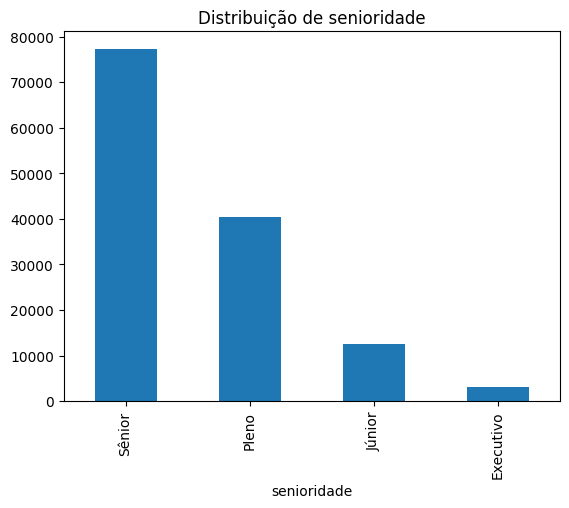

In [163]:
df_limpo['senioridade'].value_counts().plot(kind='bar', title = "Distribuição de senioridade")
# Conta a frequência de cada valor único na coluna 'senioridade' e gera um gráfico de barras

In [164]:
import seaborn as sns
# Seaborn é uma biblioteca de visualização de dados baseada no Matplotlib

<Axes: xlabel='senioridade', ylabel='salario_usd'>

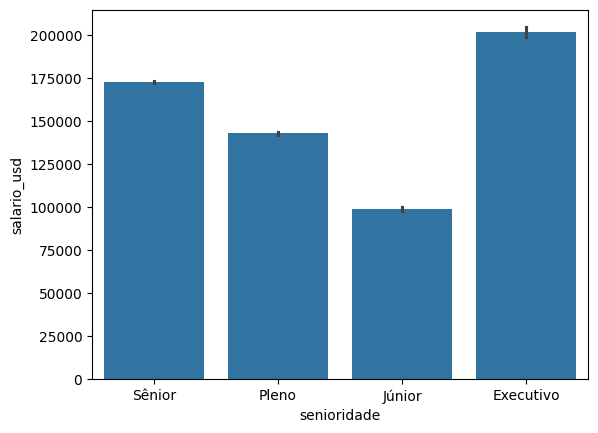

In [165]:
sns.barplot(data=df_limpo, x='senioridade', y='salario_usd')
#gera um gráfico de barras usando seaborn

In [166]:
import matplotlib.pyplot as plt
# Matplotlib é uma biblioteca para criar e visualizar gráficos em Python.

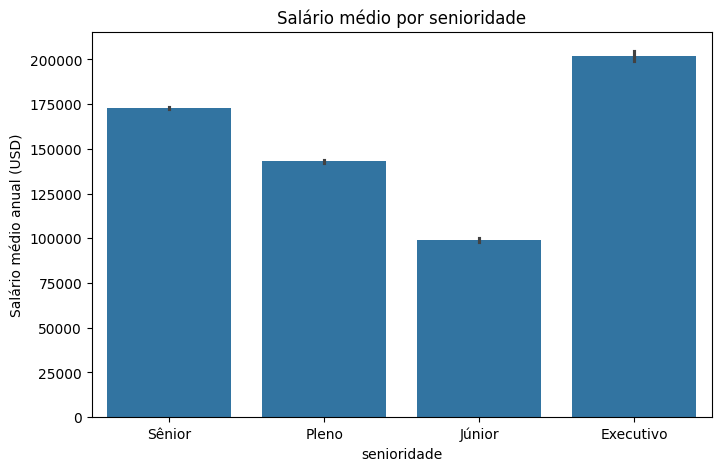

In [167]:
plt.figure(figsize=(8, 5))
# Cria um gráfico com o tamanho espefico

sns.barplot(data=df_limpo, x='senioridade', y='salario_usd')
# Gráfico de barras usando seaborn

plt.title('Salário médio por senioridade')
# Define o título do gráfico

plt.xlabel('senioridade')
# Define o rótulo do eixo X

plt.ylabel('Salário médio anual (USD)')
# Define o rótulo do eixo y

plt.show()
# Exibe o gráfico

In [168]:
df_limpo.groupby('senioridade')['salario_usd'].mean().sort_values(ascending=False)
# Agrupa o 'df_limpo' pela coluna 'senioridade'

,salario_usd
senioridade,
Executivo,202027.667813
Sênior,172850.838301
Pleno,143044.845979
Júnior,99034.963267


In [169]:
ordem = df_limpo.groupby('senioridade')['salario_usd'].mean().sort_values(ascending=False).index
# Calcula a média do 'salario_usd para cada 'senioridade'

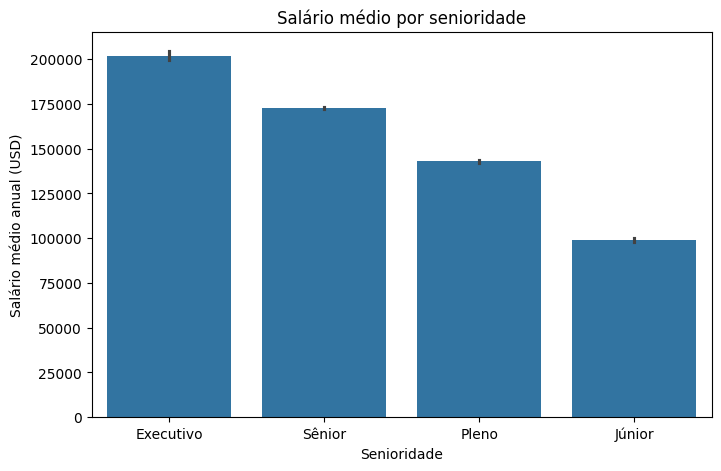

In [170]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df_limpo, x='senioridade', y='salario_usd', order=ordem)

plt.title('Salário médio por senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio anual (USD)')

plt.show()

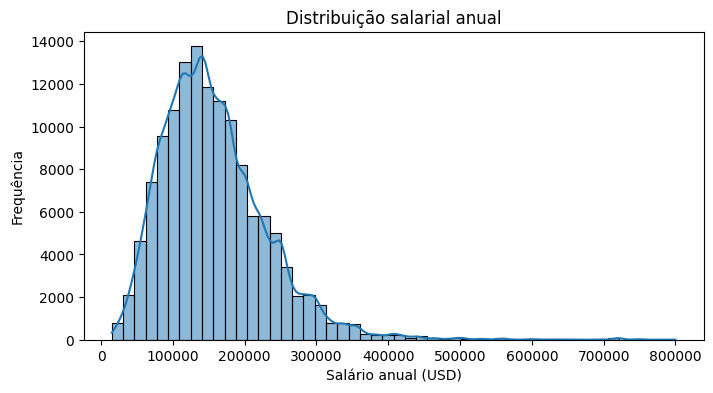

In [171]:
plt.figure(figsize=(8, 4))

sns.histplot(df_limpo['salario_usd'], bins = 50, kde=True)
# Gera um histograma da coluna salário do 'df_limpo'

plt.title('Distribuição salarial anual')
plt.xlabel('Salário anual (USD)')
plt.ylabel('Frequência')

plt.show()

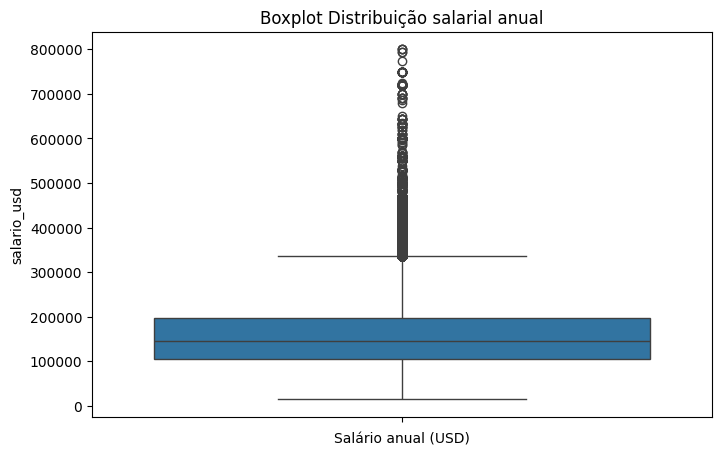

In [172]:
plt.figure(figsize= (8,5))

sns.boxplot(df_limpo['salario_usd'])
# Gera um boxplot da coluna 'salario_usd' do 'df_limpo'.

plt.title('Boxplot Distribuição salarial anual')
plt.xlabel('Salário anual (USD)')


plt.show()

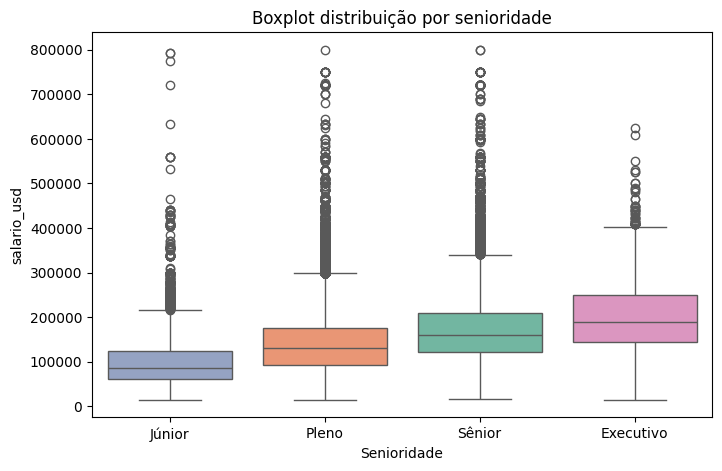

In [174]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior', 'Executivo']

plt.figure(figsize=(8,5))

sns.boxplot(x = 'senioridade', y = 'salario_usd', data = df_limpo, order = ordem_senioridade, palette = 'Set2', hue = 'senioridade')

plt.title('Boxplot distribuição por senioridade')
plt.xlabel('Senioridade')

plt.show()

In [175]:
import plotly.express as px
# Plotly Express é uma biblioteca de visualização de dados de alto nível que facilita criar gráficos interativos

In [176]:
df_media_salario = df_limpo.groupby('senioridade')['salario_usd'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(
    df_media_salario, # O DataFrame a ser usado para criar o gráfico.
    x='senioridade',
    y='salario_usd',
    title='Média Salarial por Senioridade (USD)',
    labels={'senioridade': 'Nível de Senioridade', 'salario_usd': 'Média Salarial Anual (USD)'}, # Personaliza os rótulos dos eixos.
    color='senioridade', # Atribui cores diferentes a cada barra com base na 'senioridade'.
    color_discrete_sequence=px.colors.qualitative.Set2 # Define uma paleta de cores específica ('Set2') para as barras.
)

fig.update_layout(xaxis_title='Nível de Senioridade', yaxis_title='Média Salarial Anual (USD)')
# Atualiza o layout do gráfico, definindo títulos mais descritivos para os eixos X e Y.

fig.show()

In [177]:
remoto_contagem = df_limpo ['txRemoto'].value_counts().reset_index()
# Agrupa 'df_limpo' pela coluna 'txRemoto', conta a frequência de cada valor único, e então converte o resultado em um DF
# resetando o índice.

remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
# Renomeia as colunas do novo DF para 'tipo_trabalho' e 'quantidade'

fig = px.pie(
    remoto_contagem, # O DF que contém os dados para o gráfico de pizza.
    names = 'tipo_trabalho', # Define a coluna 'tipo_trabalho' para os rótulos das fatias do gráfico.
    values = 'quantidade', # Define a coluna 'quantidade' para determinar o tamanho de cada fatia.
    title='Proporção dos tipos de trabalho'
)

fig.show()

In [178]:
remoto_contagem = df_limpo ['txRemoto'].value_counts().reset_index()

remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(
    remoto_contagem,
    names = 'tipo_trabalho',
    values = 'quantidade',
    title='Proporção dos tipos de trabalho',
    hole=0.5 # Cria um 'buraco' no centro do gráfico de pizza, transformando-o em um gráfico de donut.
)

fig.update_traces(textinfo='percent+label')
# Atualiza os traços do gráfico para exibir a porcentagem e o rótulo de cada fatia diretamente no gráfico.

fig.show()

In [179]:
df_data_scientist = df_limpo[df_limpo['cargo'] == 'Data Scientist']
# Filtrar o DF para incluir apenas o cargo de 'Data Scientist'

df_media_salario_ds_pais = df_data_scientist.groupby('paisEmpresa')['salario_usd'].mean().sort_values(ascending=False).reset_index()
# Agrupa o DF por 'paisEmpresa' e calcula a média do salário para cada país.

fig = px.bar(
    df_media_salario_ds_pais,
    x='paisEmpresa',
    y='salario_usd',
    title='Salário Médio de Data Scientists por País (USD)',
    labels={'paisEmpresa': 'País da Empresa', 'salario_usd': 'Média Salarial Anual (USD)'},
    color='paisEmpresa',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='País da Empresa',
    yaxis_title='Média Salarial Anual (USD)',
    xaxis_tickangle=-45 # Rotacionar os rótulos do eixo X para melhor legibilidade
)

fig.show()

In [180]:
pip install pycountry

In [181]:
import pycountry

# Função para converter códigos de país ISO-2 (Ex: 'US') para ISO-3 (Ex: 'USA').
def iso2_to_iso3(code):
    try:
        # Tenta obter o objeto país pelo código ISO-2 e retorna seu código ISO-3.
        return pycountry.countries.get(alpha_2=code).alpha_3
    except: # Se o código não for encontrado, retorna None.
        return None


df_limpo['residencia_iso3'] = df_limpo['paisFunc'].apply(iso2_to_iso3)


df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']

media_ds_pais = df_ds.groupby('residencia_iso3')['salario_usd'].mean().reset_index()

# Gera um mapa coroplético interativo usando Plotly Express.
fig = px.choropleth(
    media_ds_pais,
    locations='residencia_iso3', # Coluna que contém os códigos ISO-3 dos países para o mapeamento.
    color='salario_usd',
    color_continuous_scale='rdylgn', # Escala de cores contínua (Red-Yellow-Green).
    title='Salário médio de Cientista de Dados por país',
    labels={'salario_usd': 'Salário médio (USD)', 'residencia_iso3': 'País'} # Rótulos para a legenda e tooltip.
)

fig.show()

In [182]:
df_limpo.head()

,ano,senioridade,tipoEmprego,cargo,salario,moeda,salario_usd,paisFunc,txRemoto,paisEmpresa,porte,residencia_iso3
0,2025,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Médio,USA
1,2025,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Médio,USA
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Médio,AUS
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Médio,AUS
4,2025,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Médio,USA


In [183]:
df_limpo.to_csv('analise-salario-dados.csv', index=False)